# Master BigData UCM 2025-26

## 1. Datos vehículos a la venta 2024 en ES

Propósito:

- Generar un treemap interactivo usando la librería plotly a partir de los datos de vehículos a la venta en España a finales de 2024
- Consultar el script 01b_lectura_datos_coches_ES_2024 sobre el origen y pre-proceso necesario para manejar estos datos, así como los nombres de variables que se manejarán. 
  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


### Carga de datos



In [2]:
df_sp2024= pd.read_pickle("datos_vehiculos_ES_2024.pkl")

In [3]:
df_sp2024.shape

(5237, 16)

In [4]:
df_sp2024.describe(include = 'all')

,Mk,Cn,Ct,Ft,m (kg),ep (KW),ec (cm3),z (Wh/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Fuel consumption,Electric range (km),total_registros,last_date
count,5237,5236,5237,5237,5236.000000,5228.000000,4514.000000,1310.000000,5235.000000,0,0,0,3615.000000,1309.000000,5237.00000,5237
unique,75,1899,1,8,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,252
top,FORD,TOURNEO CUSTOM,M1,petrol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-30
freq,963,256,5237,2154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1271
mean,NaN,NaN,NaN,NaN,1807.823147,131.286534,1885.421134,185.452672,126.397708,NaN,NaN,NaN,5.944371,264.252101,201.62975,NaN
std,NaN,NaN,NaN,NaN,406.607704,82.745225,701.916127,36.553806,76.956617,NaN,NaN,NaN,2.506970,199.549111,683.61197,NaN
min,NaN,NaN,NaN,NaN,865.000000,8.000000,875.000000,101.000000,0.000000,NaN,NaN,NaN,0.300000,12.000000,1.00000,NaN
25%,NaN,NaN,NaN,NaN,1489.000000,88.000000,1497.000000,158.000000,87.500000,NaN,NaN,NaN,5.100000,63.000000,2.00000,NaN
50%,NaN,NaN,NaN,NaN,1744.000000,110.000000,1968.000000,177.000000,134.000000,NaN,NaN,NaN,5.800000,274.000000,13.00000,NaN
75%,NaN,NaN,NaN,NaN,2130.000000,140.000000,1997.000000,201.750000,179.000000,NaN,NaN,NaN,7.300000,434.000000,92.00000,NaN


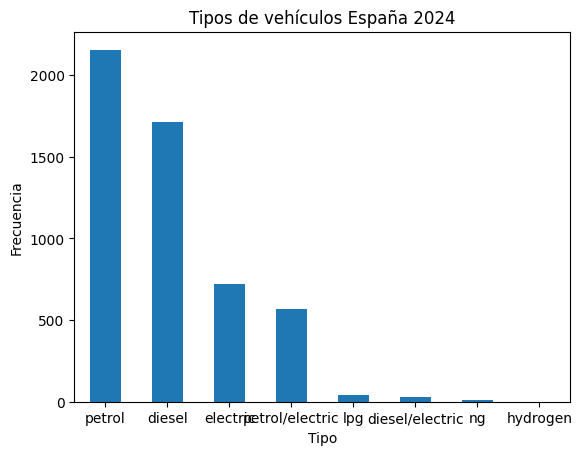

In [5]:
count_classes = df_sp2024['Ft'].value_counts(sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Tipos de vehículos España 2024")
plt.xlabel("Tipo")
plt.ylabel("Frecuencia");

In [6]:
fig = px.histogram(
    df_sp2024,
    x='Ft',
    title='Tipos de vehículos España 2024',
    color='Ft',  # Opcional: para darle color a cada barra
    text_auto = True # Muestra el valor sobre cada barra
)

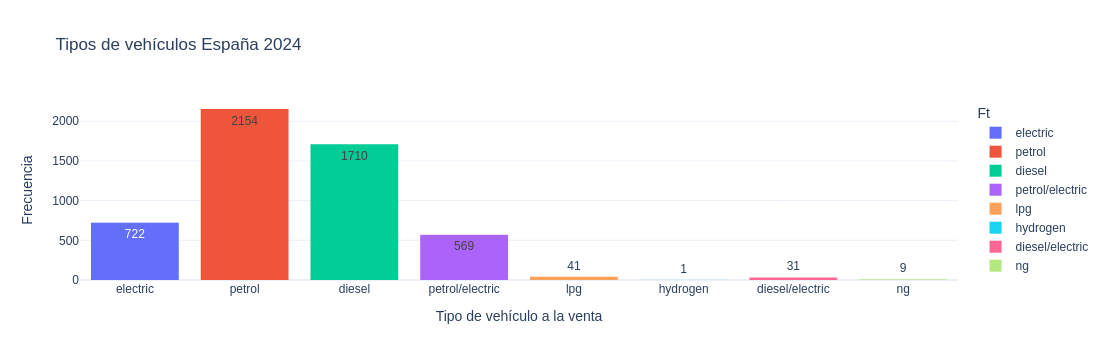

In [7]:
# Mejorar estilo
fig.update_layout(
    xaxis_title='Tipo de vehículo a la venta',
    yaxis_title='Frecuencia',
    template='plotly_white'
)

fig.show()

# Preparación de tabla para treemap

In [8]:
para_treemap = df_sp2024[["Mk", 
                   "Ft"]].value_counts()

In [9]:
para_treemap

Mk             Ft             
FORD           diesel             509
MERCEDES-BENZ  diesel             294
FORD           petrol             274
PEUGEOT        petrol             149
VOLKSWAGEN     petrol             141
                                 ... 
SPORTEQUIPE    diesel               1
SSANGYONG      electric             1
SUZUKI         petrol/electric      1
YUDO           electric             1
ZHIDOU         electric             1
Name: count, Length: 186, dtype: int64

In [10]:
para_tree2 = para_treemap.reset_index(name = "count")

In [11]:
para_tree2

,Mk,Ft,count
0,FORD,diesel,509
1,MERCEDES-BENZ,diesel,294
2,FORD,petrol,274
3,PEUGEOT,petrol,149
4,VOLKSWAGEN,petrol,141
...,...,...,...
181,SPORTEQUIPE,diesel,1
182,SSANGYONG,electric,1
183,SUZUKI,petrol/electric,1
184,YUDO,electric,1


In [12]:
para_tree2.dtypes

Mk         str
Ft         str
count    int64
dtype: object

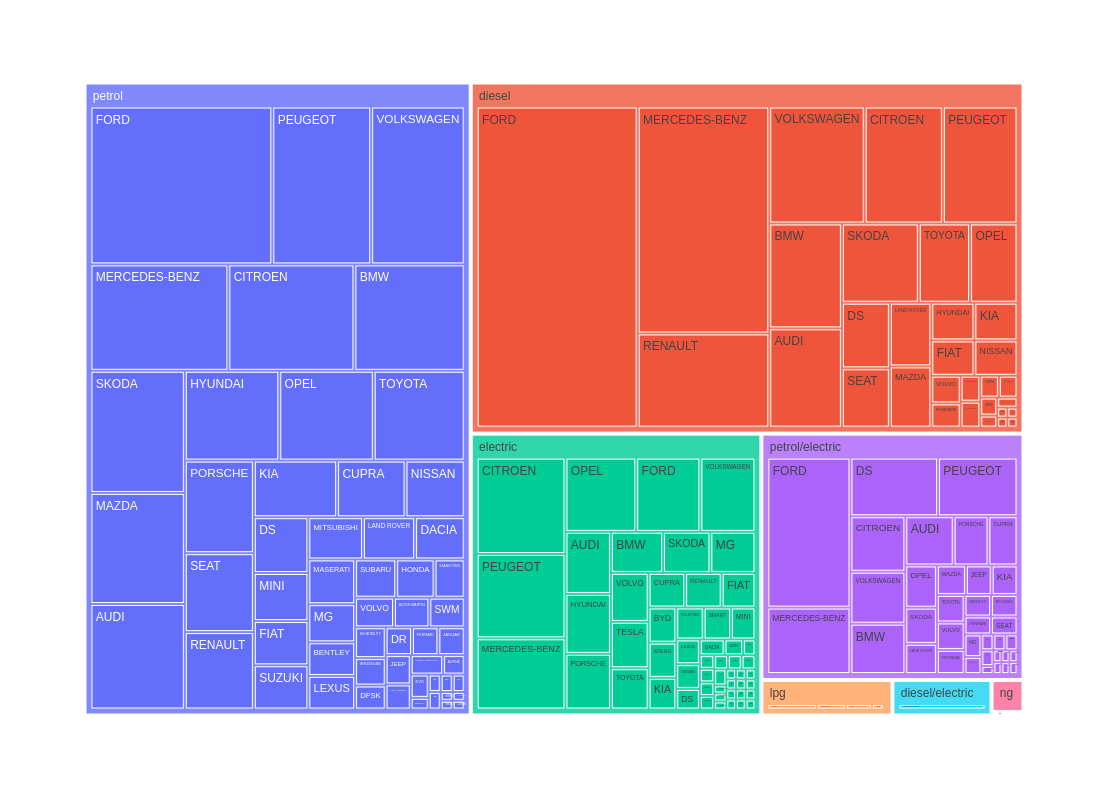

In [13]:
# plot it
fig = px.treemap(para_tree2, 
                 path = ['Ft', 'Mk'],
                 values = 'count',
                width = 1000,
                height = 800)

fig.show()

In [14]:
fig.write_html("my_treemap.html")

# Treemap de emisiones CO2 (solo vehículos de combustión)

## Primera versión

In [15]:
data = df_sp2024[df_sp2024['Ft'] != 'electric']
data.shape

(4515, 16)

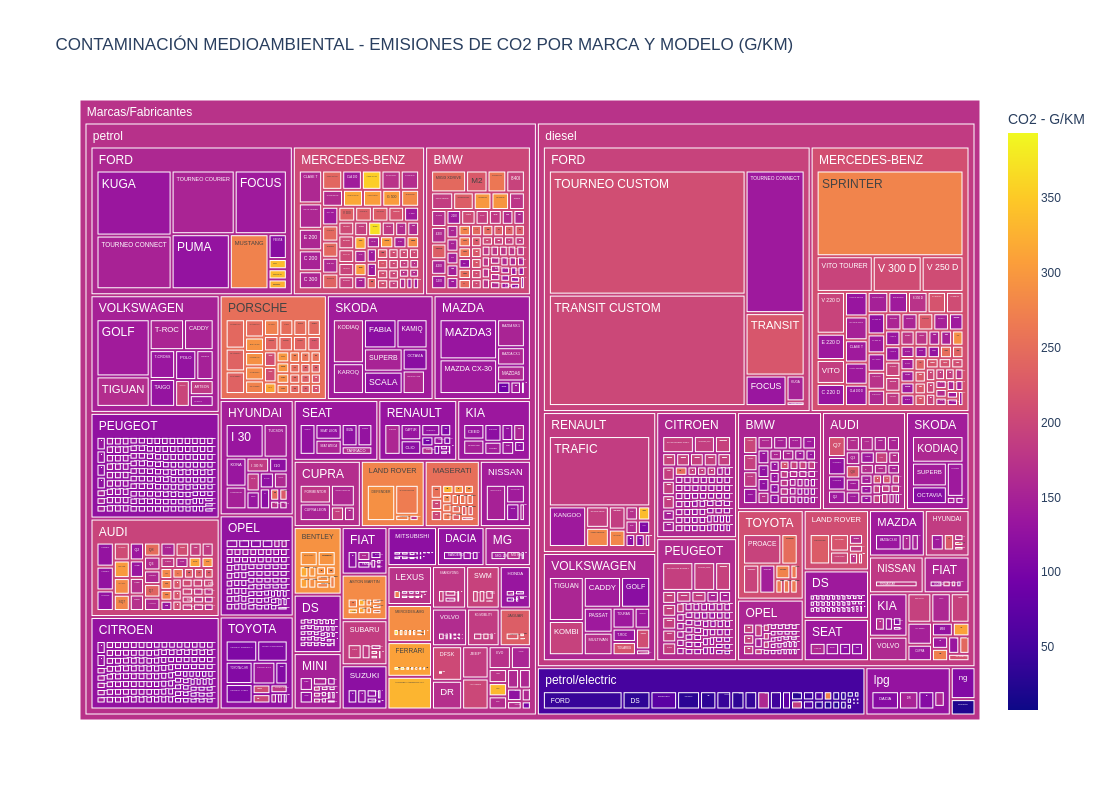

In [16]:
fig = px.treemap(data, 
                 title=("CONTAMINACIÓN MEDIOAMBIENTAL - EMISIONES DE CO2 POR MARCA Y MODELO (G/KM)"),
                 path=[px.Constant('Marcas/Fabricantes'),
                       'Ft',
                       'Mk', 
                       'Cn'],
                 values='Ewltp (g/km)',
                 color='Ewltp (g/km)', 
                 labels={'Ewltp (g/km)':'CO2 - G/KM'},
                 width = 1000,
                 height = 800)
fig.show()

In [17]:
para_treemap_2 = data[["Mk",
                       "Ft",
                       "Cn",
                       'Ewltp (g/km)'   ]].value_counts()

In [18]:
para_treemap_2

Mk             Ft               Cn               Ewltp (g/km)
MERCEDES-BENZ  diesel           SPRINTER         283.0           35
FORD           diesel           TRANSIT CUSTOM   194.0           25
               petrol           TOURNEO COURIER  153.0           18
               diesel           TOURNEO CUSTOM   196.0           17
               petrol/electric  TOURNEO CUSTOM   41.0            17
                                                                 ..
VOLVO          petrol/electric  XC60             23.0             1
               diesel           XC90             183.0            1
               petrol           XC90             192.0            1
               petrol/electric  XC90             27.0             1
                                                 30.0             1
Name: count, Length: 3263, dtype: int64

In [19]:
para_tree2 = para_treemap_2.reset_index(name = "count")

In [20]:
para_tree2

,Mk,Ft,Cn,Ewltp (g/km),count
0,MERCEDES-BENZ,diesel,SPRINTER,283.0,35
1,FORD,diesel,TRANSIT CUSTOM,194.0,25
2,FORD,petrol,TOURNEO COURIER,153.0,18
3,FORD,diesel,TOURNEO CUSTOM,196.0,17
4,FORD,petrol/electric,TOURNEO CUSTOM,41.0,17
...,...,...,...,...,...
3258,VOLVO,petrol/electric,XC60,23.0,1
3259,VOLVO,diesel,XC90,183.0,1
3260,VOLVO,petrol,XC90,192.0,1
3261,VOLVO,petrol/electric,XC90,27.0,1


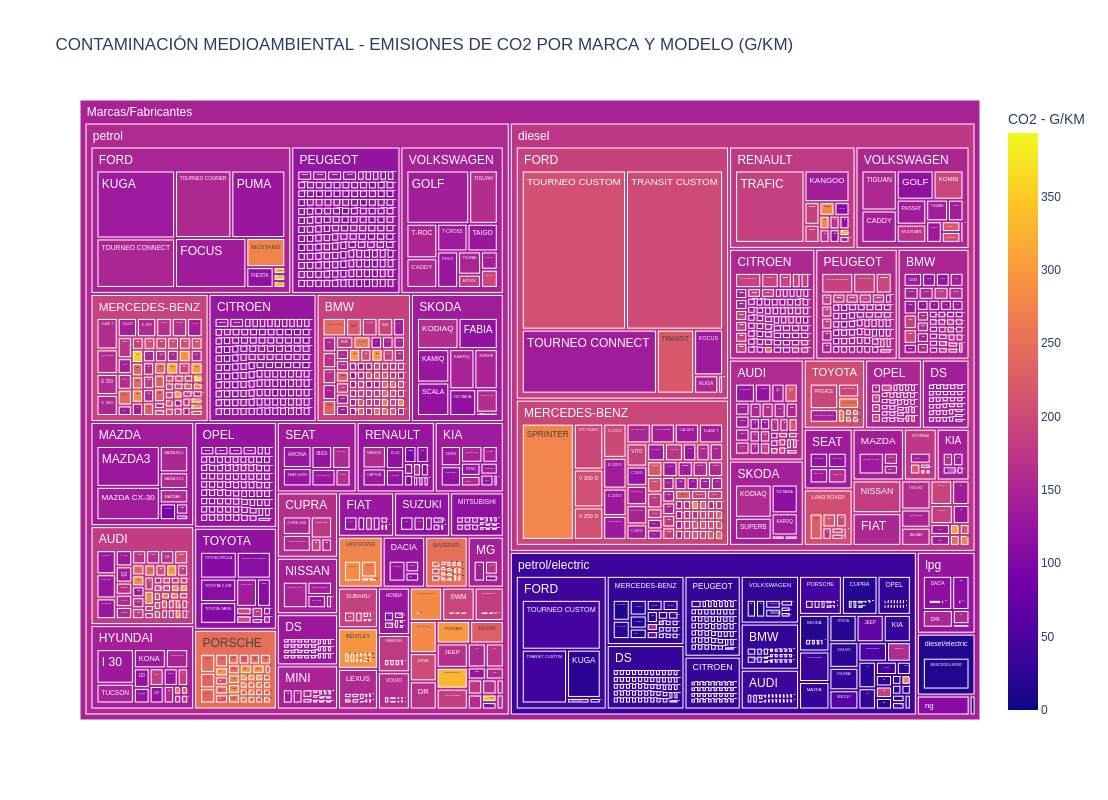

In [21]:

fig = px.treemap(para_tree2, 
                 title=("CONTAMINACIÓN MEDIOAMBIENTAL - EMISIONES DE CO2 POR MARCA Y MODELO (G/KM)"),
                 path=[px.Constant('Marcas/Fabricantes'),
                       'Ft',
                       'Mk', 
                       'Cn'],
                 values='count',
                 color='Ewltp (g/km)', 
                 labels={'Ewltp (g/km)':'CO2 - G/KM'},
                 width = 1000,
                 height = 800)
fig.show()